In [1]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [2]:
!pip install -q kornia

In [3]:
# ==========================================
# 🗂  Unique Run Folder Setup
# Every run creates: runs/YYYYMMDD_HHMMSS_leadNd/
#   config.json                    — all hyper-parameters
#   runtime.log                    — epoch logs + timing
#   chart_*_config.json            — per-chart render config
#   convnext_preupsample_training_curves.png — loss/RMSE charts
#   convnext_preupsample_eval_<date>.png     — spatial eval chart
#   metrics.csv                    — final test metrics
# ==========================================
import os
import json as _json
import datetime as _dt

_run_start = _dt.datetime.now()
_run_id    = _run_start.strftime('%Y%m%d_%H%M%S')

# Temporary placeholder; RUN_DIR is refreshed once lead_days is known (Config cell)
RUN_DIR   = os.path.join('runs', f'{_run_id}_lead1d')
os.makedirs(RUN_DIR, exist_ok=True)
print(f'Run folder (placeholder): {RUN_DIR}')

# ── Runtime log helper ──────────────────────────────────────────────────
_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')

VAR_LABELS = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]

def _log(msg: str):
    ts   = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{ts}] {msg}'
    print(line)
    with open(_LOG_PATH, 'a') as _f:
        _f.write(line + '\n')

_log(f'=== Run started  (id={_run_id}) ===')
_log(f'Run dir: {RUN_DIR}')

# ── Chart-save helper ───────────────────────────────────────────────────
def save_fig(fig, name: str, dpi: int = 150):
    path = os.path.join(RUN_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _log(f'Chart saved → {path}')
    return path


Run folder (placeholder): runs/20260408_184448_lead1d
[2026-04-08 18:44:48] === Run started  (id=20260408_184448) ===
[2026-04-08 18:44:48] Run dir: runs/20260408_184448_lead1d


## Import Library

In [4]:
import datetime
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
import kornia

In [5]:
## Config
# Perfect Prognosis: X = low-res ERA5, Y = high-res ERA5
# No NWP model lead time — set lead_days = 0 to mark PP scenario
lead_days = 0
scale = 6
seed = 42
BATCH_SIZE = 128

# Date-based split boundaries (inclusive)
train_start_date = "2018-01-01"
train_end_date   = "2021-12-31"
val_start_date   = "2022-01-01"
val_end_date     = "2022-06-30"
test_start_date  = "2022-07-01"
test_end_date    = "2022-12-31"

# ── Refresh RUN_DIR now that lead_days is defined ──────────────────────
RUN_DIR = os.path.join('runs', f'{_run_id}')
os.makedirs(RUN_DIR, exist_ok=True)
_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')
print(f'Run folder: {RUN_DIR}')

VAR_LABELS_VIZ = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
target_date = np.datetime64("2022-08-01")

# ── Persist config ──────────────────────────────────────────────────────
_config = {
    'scenario'         : 'scenario2-convnext-mae-preupsample-perfect-prognosis',
    'lead_days'        : lead_days,
    'run_id'           : _run_id,
    'run_dir'          : RUN_DIR,
    'scale'            : scale,
    'seed'             : seed,
    'BATCH_SIZE'       : BATCH_SIZE,
    'train_start_date' : train_start_date,
    'train_end_date'   : train_end_date,
    'val_start_date'   : val_start_date,
    'val_end_date'     : val_end_date,
    'test_start_date'  : test_start_date,
    'test_end_date'    : test_end_date,
    'started_at'       : _run_start.isoformat(),
}
_cfg_path = os.path.join(RUN_DIR, 'config.json')
with open(_cfg_path, 'w') as _f:
    _json.dump(_config, _f, indent=2)
_log(f'Config saved → {_cfg_path}')

Run folder: runs/20260408_184448
[2026-04-08 18:44:50] Config saved → runs/20260408_184448/config.json


In [6]:
# Reproducibility
import random

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

## Load Datasets

In [7]:
ds_hr = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

## Cropping data to this dimension
- Low-res shape  : 24 32
- High-res shape : 144 192

In [8]:
import numpy as np
import xarray as xr
import xesmf as xe

# =========================================
# Truth is the constraint — build LR from HR truth
# =========================================
scale = 6

ds_hr = ds_hr.sortby("latitude")  # ensure south → north

tr_lons = ds_hr.longitude.values
tr_lats = ds_hr.latitude.values

# Pseudo-forecast grid from truth stride (Perfect Prognosis setup)
fc_lons = tr_lons[::scale]
fc_lats = tr_lats[::scale]

# ── Force start like forecast-correction notebook ──
lon_start = 90.0
lat_start = -13.5

# Snap to available pseudo-forecast coords
lon_start = float(fc_lons[np.argmin(np.abs(fc_lons - lon_start))])
lat_start = float(fc_lats[np.argmin(np.abs(fc_lats - lat_start))])

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx
avail_lat = len(tr_lats) - lat_start_idx

# ── Max LR points truth can support ──
max_fc_lon = avail_lon // scale
max_fc_lat = avail_lat // scale

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Slice truth by exact count (HR target) ──
ds_tr = ds_hr.isel(
    longitude=slice(lon_start_idx, lon_start_idx + max_fc_lon * scale),
    latitude=slice(lat_start_idx, lat_start_idx + max_fc_lat * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

# ── Build LR grid from HR stride ──
lr_lons = ds_tr.longitude.values[::scale]
lr_lats = ds_tr.latitude.values[::scale]

ds_lr_grid = xr.Dataset(
    coords={
        "lat": ("lat", lr_lats),
        "lon": ("lon", lr_lons),
    }
)

# ── Regrid HR -> LR with xESMF ──
ds_hr_in = ds_tr.rename({"latitude": "lat", "longitude": "lon"})
regridder_hr2lr = xe.Regridder(
    ds_hr_in,
    ds_lr_grid,
    method="bilinear",
    periodic=False,
    reuse_weights=False,
    ignore_degenerate=True,
)
ds_lr = regridder_hr2lr(ds_hr_in, keep_attrs=True).rename({"lat": "latitude", "lon": "longitude"})

LOW_LON = len(ds_lr.longitude)
LOW_LAT = len(ds_lr.latitude)

print(f"\nLow Resolution domain : lon {ds_lr.longitude.values[0]:.2f}→{ds_lr.longitude.values[-1]:.2f}"
      f"  lat {ds_lr.latitude.values[0]:.2f}→{ds_lr.latitude.values[-1]:.2f}")
print(f"high resolution domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal low resolution grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_lr.longitude.values, atol=1e-8)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_lr.latitude.values,  atol=1e-8)
assert lon_ok and lat_ok, "LR grid does not align with HR stride — check scale factor!"
print(f"Grid alignment check passed (lon_ok={lon_ok}, lat_ok={lat_ok})")

# ── Perfect Prognosis aliases ────────────────────────────────────────────
# Scenario 2 is Perfect Prognosis: the "forecast" input (X) is ERA5 itself
# degraded to low resolution.  There is no separate NWP model output.
#   ds_fc         → low-res ERA5  (predictor / pseudo-forecast, 24×32)
#   ds_tr_aligned → high-res ERA5 truth, cropped to the same domain (144×192)
ds_fc         = ds_lr   # alias — used throughout downstream cells
ds_tr_aligned = ds_tr   # alias — used throughout downstream cells
print("Perfect Prognosis aliases set:")
print(f"  ds_fc         = ds_lr  ({LOW_LAT}×{LOW_LON})")
print(f"  ds_tr_aligned = ds_tr  ({HIGH_LAT}×{HIGH_LON})")


lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5



Low Resolution domain : lon 90.00→136.50  lat -13.50→21.00
high resolution domain    : lon 90.00→137.75  lat -13.50→22.25

Final low resolution grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Grid alignment check passed (lon_ok=True, lat_ok=True)
Perfect Prognosis aliases set:
  ds_fc         = ds_lr  (24×32)
  ds_tr_aligned = ds_tr  (144×192)


## Check Missing Value

In [9]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

# check_nan_summary(ds_lr, "Low-res")
# check_nan_summary(ds_hr, "Truth (High-res)")

## Data model preparation

In [10]:
# ==========================================
# 1️⃣ Variable stacking
# ==========================================
VARS = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]
TP_IDX = VARS.index("total_precipitation_24hr")  # index 3

# Stack forecast (low-res): (time, channel, lat, lon)
X = np.stack(
    [ds_lr[v].values for v in VARS],
    axis=1
).astype(np.float32)

# Stack truth (high-res): (time, channel, lat, lon)
Y = np.stack(
    [ds_tr[v].values for v in VARS],
    axis=1
).astype(np.float32)

# ── Fill NaNs in forecast (X) before any processing ──────────────
# X has ~0.027 % NaN values (confirmed in missing-value check above).
# Strategy: per-channel spatial mean imputation — fast and unbiased.
for _c in range(X.shape[1]):
    _ch   = X[:, _c, :, :]                          # (N, H, W)
    _mask = np.isnan(_ch)
    if _mask.any():
        _fill = np.nanmean(_ch)                     # scalar fallback
        _ch[_mask] = _fill
        X[:, _c, :, :] = _ch
        print(f"  X channel {_c}: filled {_mask.sum()} NaNs with mean={_fill:.4f}")
assert not np.isnan(X).any(), "X still contains NaNs after imputation!"

# ── Fill NaNs in truth (Y) ───────────────────────────────────────────
for _c in range(Y.shape[1]):
    _ch   = Y[:, _c, :, :]
    _mask = np.isnan(_ch)
    if _mask.any():
        _fill = np.nanmean(_ch)
        _ch[_mask] = _fill
        Y[:, _c, :, :] = _ch
        print(f"  Y channel {_c}: filled {_mask.sum()} NaNs with mean={_fill:.4f}")
assert not np.isnan(Y).any(), "Y still contains NaNs after imputation!"
print("X NaN fill complete — no NaNs remain.")

print("Before axis check:")
print("X shape:", X.shape)  # (N, 4, 24, 32)
print("Y shape:", Y.shape)  # (N, 4, 144, 192)

# ==========================================
# 2️⃣ Axis fix (if lat/lon reversed in Y)
# ==========================================
expected_h = X.shape[2] * 6  # 144
expected_w = X.shape[3] * 6  # 192

if Y.shape[2] == expected_w and Y.shape[3] == expected_h:
    Y = np.transpose(Y, (0, 1, 3, 2))
    print("Y axes corrected")

print("Corrected shapes:")
print("X (low-res):", X.shape)
print("Y (high-res):", Y.shape)

# ==========================================
# 2.5️⃣ Upsample low-res X first (pre-upsampled setup)
# ==========================================
target_h, target_w = Y.shape[2], Y.shape[3]
X = F.interpolate(
    torch.from_numpy(X),
    size=(target_h, target_w),
    mode='bilinear',
    align_corners=False,
).numpy().astype(np.float32)
print("After interpolation upsampling:")
print("X (upsampled):", X.shape)
print("Y (target):    ", Y.shape)

# ==========================================
# 2.5 Log-transform precipitation BEFORE normalisation
# ==========================================
# Precipitation is non-negative & heavily right-skewed; log1p handles zeros safely
print(f"\nBefore log1p — X TP min/max: {X[:, TP_IDX].min():.4f} / {X[:, TP_IDX].max():.4f}")
print(f"Before log1p — Y TP min/max: {Y[:, TP_IDX].min():.4f} / {Y[:, TP_IDX].max():.4f}")

X[:, TP_IDX] = np.log1p(np.clip(X[:, TP_IDX], 0, None))
Y[:, TP_IDX] = np.log1p(np.clip(Y[:, TP_IDX], 0, None))

print(f"After  log1p — X TP min/max: {X[:, TP_IDX].min():.4f} / {X[:, TP_IDX].max():.4f}")
print(f"After  log1p — Y TP min/max: {Y[:, TP_IDX].min():.4f} / {Y[:, TP_IDX].max():.4f}")

# ==========================================
# 3️⃣ Train / Val / Test split (date-based)
#    Split BEFORE normalization!
#    Keep temporal order — no shuffle
# ==========================================
times = ds_lr.time.values  # Perfect Prognosis: use ds_lr (= ds_fc alias)
train_mask = (times >= np.datetime64(train_start_date)) & (times <= np.datetime64(train_end_date))
val_mask   = (times >= np.datetime64(val_start_date)) & (times <= np.datetime64(val_end_date))
test_mask  = (times >= np.datetime64(test_start_date)) & (times <= np.datetime64(test_end_date))

assert train_mask.any(), "No samples found for train date range"
assert val_mask.any(), "No samples found for val date range"
assert test_mask.any(), "No samples found for test date range"

X_train = X[train_mask]
X_val   = X[val_mask]
X_test  = X[test_mask]

Y_train = Y[train_mask]
Y_val   = Y[val_mask]
Y_test  = Y[test_mask]

print("\nDate-based split sizes:")
print(f"  Train : {len(X_train)} ({str(times[train_mask][0])[:10]} → {str(times[train_mask][-1])[:10]})")
print(f"  Val   : {len(X_val)} ({str(times[val_mask][0])[:10]} → {str(times[val_mask][-1])[:10]})")
print(f"  Test  : {len(X_test)} ({str(times[test_mask][0])[:10]} → {str(times[test_mask][-1])[:10]})")

# ==========================================
# 4️⃣ Normalization — train stats only!
#    X/Y now share the same grid after pre-upsampling.
# ==========================================
# X stats: (1, C, 1, 1)
X_mean = X_train.mean(axis=(0, 2, 3), keepdims=True)
X_std  = X_train.std( axis=(0, 2, 3), keepdims=True)

# Y stats: (1, C, 1, 1)
Y_mean = Y_train.mean(axis=(0, 2, 3), keepdims=True)
Y_std  = Y_train.std( axis=(0, 2, 3), keepdims=True)

X_train = (X_train - X_mean) / (X_std + 1e-6)
X_val   = (X_val   - X_mean) / (X_std + 1e-6)
X_test  = (X_test  - X_mean) / (X_std + 1e-6)

Y_train = (Y_train - Y_mean) / (Y_std + 1e-6)
Y_val   = (Y_val   - Y_mean) / (Y_std + 1e-6)
Y_test  = (Y_test  - Y_mean) / (Y_std + 1e-6)

# Save stats for denormalization at inference
# NOTE: expm1() needed after denormalising the TP channel
norm_stats = {
    "X_mean": torch.tensor(X_mean, dtype=torch.float32),
    "X_std" : torch.tensor(X_std,  dtype=torch.float32),
    "Y_mean": torch.tensor(Y_mean, dtype=torch.float32),
    "Y_std" : torch.tensor(Y_std,  dtype=torch.float32),
    "variables": VARS,
    "tp_index": TP_IDX,
    "log1p_applied": True,
    "x_preupsampled": True,
}
print("\nX norm stats per channel:")
for i, v in enumerate(VARS):
    print(f"  {v}: mean={X_mean[0,i,0,0]:.4f}, std={X_std[0,i,0,0]:.4f}")
print("Y norm stats per channel:")
for i, v in enumerate(VARS):
    print(f"  {v}: mean={Y_mean[0,i,0,0]:.4f}, std={Y_std[0,i,0,0]:.4f}")

# ==========================================
# 5️⃣ Convert to PyTorch tensors
# ==========================================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val,   dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.float32)
Y_val   = torch.tensor(Y_val,   dtype=torch.float32)
Y_test  = torch.tensor(Y_test,  dtype=torch.float32)

print("\nFinal tensor shapes:")
print(f"  X_train : {X_train.shape}")
print(f"  Y_train : {Y_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  Y_val   : {Y_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Y_test  : {Y_test.shape}")

# ==========================================
# 6️⃣ DataLoaders
# ==========================================

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    TensorDataset(X_val, Y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)
test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"\nDataLoaders ready:")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

# ==========================================
# 7️⃣ Denormalization helper (use at inference)
# ==========================================
def denormalize(tensor, mu, sig, tp_idx=TP_IDX):
    """Reverse z-score, then expm1 on the TP channel."""
    mu  = mu.to(tensor.device)
    sig = sig.to(tensor.device)
    out = tensor * (sig + 1e-6) + mu
    out[:, tp_idx] = torch.expm1(out[:, tp_idx])  # reverse log1p
    return out

X NaN fill complete — no NaNs remain.
Before axis check:
X shape: (7304, 4, 24, 32)
Y shape: (7304, 4, 144, 192)
Corrected shapes:
X (low-res): (7304, 4, 24, 32)
Y (high-res): (7304, 4, 144, 192)


After interpolation upsampling:
X (upsampled): (7304, 4, 144, 192)
Y (target):     (7304, 4, 144, 192)

Before log1p — X TP min/max: -0.0000 / 0.4259
Before log1p — Y TP min/max: -0.0000 / 0.6023


After  log1p — X TP min/max: 0.0000 / 0.3548
After  log1p — Y TP min/max: 0.0000 / 0.4715



Date-based split sizes:
  Train : 5841 (2018-01-01 → 2021-12-31)
  Val   : 721 (2022-01-01 → 2022-06-30)
  Test  : 733 (2022-07-01 → 2022-12-31)



X norm stats per channel:
  10m_u_component_of_wind: mean=-1.1941, std=3.9927
  10m_v_component_of_wind: mean=0.3375, std=3.2681
  2m_temperature: mean=300.0588, std=2.0330
  total_precipitation_24hr: mean=0.0060, std=0.0093
Y norm stats per channel:
  10m_u_component_of_wind: mean=-1.1902, std=4.0955
  10m_v_component_of_wind: mean=0.2801, std=3.3993
  2m_temperature: mean=300.0140, std=2.3289
  total_precipitation_24hr: mean=0.0061, std=0.0105



Final tensor shapes:
  X_train : torch.Size([5841, 4, 144, 192])
  Y_train : torch.Size([5841, 4, 144, 192])
  X_val   : torch.Size([721, 4, 144, 192])
  Y_val   : torch.Size([721, 4, 144, 192])
  X_test  : torch.Size([733, 4, 144, 192])
  Y_test  : torch.Size([733, 4, 144, 192])

DataLoaders ready:
  Train batches : 46
  Val batches   : 6
  Test batches  : 6


In [11]:
# ==========================================
# ConvNeXt Pre-upsample Model
# ==========================================
import torchvision.models as models


class ConvNeXtPreUpsample(nn.Module):
    """
    Input  : (B, 4, 144, 192)
    Output : (B, 4, 144, 192)
    """
    def __init__(self, in_ch=4, out_ch=4, pretrained=True):
        super().__init__()

        weights = models.ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None
        backbone = models.convnext_tiny(weights=weights)

        # Adapt ConvNeXt stem to 4-channel climate input.
        old_stem = backbone.features[0][0]
        new_stem = nn.Conv2d(
            in_ch,
            old_stem.out_channels,
            kernel_size=old_stem.kernel_size,
            stride=old_stem.stride,
            padding=old_stem.padding,
            bias=(old_stem.bias is not None),
        )
        with torch.no_grad():
            new_stem.weight[:, :3] = old_stem.weight
            if in_ch > 3:
                new_stem.weight[:, 3:] = old_stem.weight[:, :1]
            if old_stem.bias is not None:
                new_stem.bias.copy_(old_stem.bias)
        backbone.features[0][0] = new_stem

        # Keep stronger encoder depth; input is already high-res.
        self.encoder = nn.Sequential(*list(backbone.features.children())[:6])

        # Decoder restores full-resolution grid and predicts 4 channels.
        self.decode = nn.Sequential(
            nn.Conv2d(384, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Upsample(size=(144, 192), mode="bilinear", align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, out_ch, kernel_size=1),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decode(x)

        # Keep target shape consistent with Y_batch: (B, C, 144, 192).
        if x.shape[-2:] == (192, 144):
            x = x.transpose(-2, -1)
        elif x.shape[-2:] != (144, 192):
            x = F.interpolate(x, size=(144, 192), mode="bilinear", align_corners=False)

        return x


# ==========================================
# Quick sanity check
# ==========================================
if __name__ == "__main__":
    model = ConvNeXtPreUpsample(in_ch=4, out_ch=4, pretrained=False)
    dummy = torch.randn(2, 4, 144, 192)
    output = model(dummy)

    print("Input  :", dummy.shape)
    print("Output :", output.shape)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Params : {total_params:,}")

Input  : torch.Size([2, 4, 144, 192])
Output : torch.Size([2, 4, 144, 192])
Params : 13,604,068


In [12]:
class CombinedLoss(nn.Module):
    """
    Combined loss using DSSIM from Kornia.

    Modes:
    - 'dssim'      : Pure DSSIM
    - 'mae'        : Pure MAE
    - 'dssim+mse'  : alpha * DSSIM + beta * MSE
    - 'dssim+mae'  : alpha * DSSIM + beta * MAE
    """
    def __init__(self, alpha=0.8, beta=0.2, mode='dssim'):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.mode  = mode
        self.dssim = kornia.losses.SSIMLoss(window_size=11, reduction='mean')

    def _zero(self, ref: torch.Tensor) -> torch.Tensor:
        """Device-safe zero scalar."""
        return torch.tensor(0.0, device=ref.device, dtype=ref.dtype)

    def _gradient_loss(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """L1 loss on spatial gradients (sharpens edges)."""
        def grad(x):
            dy = x[:, :, 1:, :] - x[:, :, :-1, :]
            dx = x[:, :, :, 1:] - x[:, :, :, :-1]
            return dy, dx
        pred_dy,   pred_dx   = grad(pred)
        target_dy, target_dx = grad(target)
        return F.l1_loss(pred_dy, target_dy) + F.l1_loss(pred_dx, target_dx)

    def forward(self, pred: torch.Tensor, target: torch.Tensor):
        """
        Returns:
            total_loss  : scalar used for .backward()
            loss_a      : first component (detached), for logging
            loss_b      : second component (detached), for logging
        """
        if self.mode == 'dssim':
            d = self.dssim(pred, target)
            return d, d.detach(), self._zero(pred)

        elif self.mode == 'mae':
            mae = F.l1_loss(pred, target)          
            return mae, mae.detach(), self._zero(pred)

        elif self.mode == 'dssim+mse':
            d   = self.dssim(pred, target)
            mse = F.mse_loss(pred, target)
            total = self.alpha * d + self.beta * mse
            return total, d.detach(), mse.detach()

        elif self.mode == 'dssim+mae':
            d   = self.dssim(pred, target)
            mae = F.l1_loss(pred, target)
            total = self.alpha * d + self.beta * mae
            return total, d.detach(), mae.detach()

        else:
            raise ValueError(f"Unknown mode: {self.mode}")

In [13]:
def train(
    model,
    train_loader,
    val_loader,
    norm_stats,
    epochs     = 50,
    lr         = 5e-4,
    patience   = 7,
    device     = "cuda" if torch.cuda.is_available() else "cpu",
):
    _log(f"Training started  epochs={epochs} lr={lr} patience={patience}")
    _train_t0 = _dt.datetime.now()
    model = model.to(device)

    Y_mu  = norm_stats["Y_mean"]
    Y_sig = norm_stats["Y_std"]

    criterion = CombinedLoss(mode='mae').to(device)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    history = {
        "train_loss": [], "val_loss": [],
        "train_mse": [], "train_grad": [],
        "val_metrics": [],
    }
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, epochs + 1):

        # ── Train ──────────────────────────────
        model.train()
        train_losses, train_mses, train_grads = [], [], []

        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss, mse, grad = criterion(pred, Y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())
            train_mses.append(mse.item())
            train_grads.append(grad.item())

        scheduler.step()

        # ── Validate ───────────────────────────
        model.eval()
        val_losses   = []
        all_preds    = []
        all_targets  = []

        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)
                pred    = model(X_batch)
                loss, _, _ = criterion(pred, Y_batch)
                val_losses.append(loss.item())
                all_preds.append(pred.cpu())
                all_targets.append(Y_batch.cpu())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)

        # Metrics on full val set
        all_preds   = torch.cat(all_preds,   dim=0)
        all_targets = torch.cat(all_targets, dim=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # ── Logging ────────────────────────────
        _emsg = (f"Epoch [{epoch:03d}/{epochs}] "
              f"train={train_loss:.4f} "
              f"val={val_loss:.4f}  lr={scheduler.get_last_lr()[0]:.2e}")
        print(_emsg)
        _log(_emsg)

        # ── Checkpoint + Early Stopping ────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                "epoch"      : epoch,
                "model_state": model.state_dict(),
                "optimizer"  : optimizer.state_dict(),
                "val_loss"   : val_loss,
                "X_mean"     : norm_stats["X_mean"].clone(),
                "X_std"      : norm_stats["X_std"].clone(),
                "Y_mean"     : norm_stats["Y_mean"].clone(),
                "Y_std"      : norm_stats["Y_std"].clone(),
                "variables"  : VARS,
                "tp_index"   : TP_IDX,
                "log1p_applied": True,
            }, os.path.join(RUN_DIR, "best_model.pt"))
            print(f"  💾 Saved best model (val={val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⏹ Early stopping at epoch {epoch} — no improvement for {patience} epochs.")
                # Restore best weights
                best_ckpt = torch.load(os.path.join(RUN_DIR, "best_model.pt"), map_location=device, weights_only=False)
                model.load_state_dict(best_ckpt["model_state"])
                print(f"  Restored best weights from epoch {best_ckpt['epoch']} (val={best_ckpt['val_loss']:.4f})")
                break

    _elapsed = _dt.datetime.now() - _train_t0
    _log(f"Training finished  elapsed={str(_elapsed).split(chr(46))[0]}  best_val_loss={best_val_loss:.6f}")
    return history

In [14]:
model   = ConvNeXtPreUpsample(in_ch=4, out_ch=4, pretrained=True)
history = train(
    model, train_loader, val_loader, norm_stats,
    epochs=100, lr=5e-4,
)

[2026-04-08 18:45:34] Training started  epochs=100 lr=0.0005 patience=7


Epoch [001/100] train=0.3548 val=0.2760  lr=5.00e-04
[2026-04-08 18:46:02] Epoch [001/100] train=0.3548 val=0.2760  lr=5.00e-04
  💾 Saved best model (val=0.2760)


Epoch [002/100] train=0.2479 val=0.2417  lr=5.00e-04
[2026-04-08 18:46:28] Epoch [002/100] train=0.2479 val=0.2417  lr=5.00e-04
  💾 Saved best model (val=0.2417)


Epoch [003/100] train=0.2309 val=0.2308  lr=4.99e-04
[2026-04-08 18:46:54] Epoch [003/100] train=0.2309 val=0.2308  lr=4.99e-04
  💾 Saved best model (val=0.2308)


Epoch [004/100] train=0.2213 val=0.2218  lr=4.98e-04
[2026-04-08 18:47:20] Epoch [004/100] train=0.2213 val=0.2218  lr=4.98e-04
  💾 Saved best model (val=0.2218)


...

Epoch [096/100] train=0.1538 val=0.1622  lr=2.97e-06
[2026-04-08 19:27:14] Epoch [096/100] train=0.1538 val=0.1622  lr=2.97e-06
  💾 Saved best model (val=0.1622)


Epoch [097/100] train=0.1536 val=0.1623  lr=2.11e-06
[2026-04-08 19:27:40] Epoch [097/100] train=0.1536 val=0.1623  lr=2.11e-06


Epoch [098/100] train=0.1539 val=0.1625  lr=1.49e-06
[2026-04-08 19:28:06] Epoch [098/100] train=0.1539 val=0.1625  lr=1.49e-06


Epoch [099/100] train=0.1538 val=0.1622  lr=1.12e-06
[2026-04-08 19:28:32] Epoch [099/100] train=0.1538 val=0.1622  lr=1.12e-06


Epoch [100/100] train=0.1542 val=0.1625  lr=1.00e-06
[2026-04-08 19:28:58] Epoch [100/100] train=0.1542 val=0.1625  lr=1.00e-06
[2026-04-08 19:28:58] Training finished  elapsed=0:43:24  best_val_loss=0.162197


[2026-04-08 19:28:58] Chart config saved → chart_training_curves_config.json
[2026-04-08 19:28:58] Chart saved → runs/20260408_184448/convnext_preupsample_training_curves.png


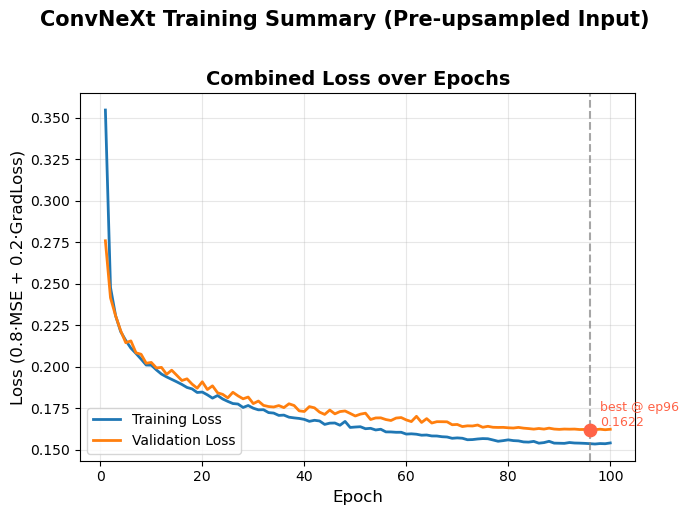


Final Training Loss: 0.154244
Final Validation Loss: 0.162484


In [15]:
# ── Save chart config ───────────────────────────────────────────────────
_chart1_cfg = {
    'chart'         : 'training_curves',
    'figsize'       : [14, 5],
    'loss_alpha'    : 0.8,
    'loss_beta'     : 0.2,
    'best_epoch'    : int(np.argmin(history['val_loss']) + 1),
    'best_val_loss' : float(min(history['val_loss'])),
}
_json.dump(_chart1_cfg, open(os.path.join(RUN_DIR, 'chart_training_curves_config.json'), 'w'), indent=2)
_log('Chart config saved → chart_training_curves_config.json')

import matplotlib.pyplot as plt

fig, (ax1) = plt.subplots(1, 1, figsize=(7, 5))

epochs_range = range(1, len(history["train_loss"]) + 1)

# ── Left: Loss (combined = 0.8*MSE + 0.2*GradLoss) ──
ax1.plot(epochs_range, history["train_loss"], label="Training Loss", linewidth=2)
ax1.plot(epochs_range, history["val_loss"],   label="Validation Loss", linewidth=2)

best_epoch = np.argmin(history["val_loss"]) + 1
best_loss  = min(history["val_loss"])
ax1.axvline(best_epoch, color="gray", linestyle="--", alpha=0.7)
ax1.scatter([best_epoch], [best_loss], color="tomato", zorder=5, s=80)
ax1.annotate(
    f"best @ ep{best_epoch}\n{best_loss:.4f}",
    xy=(best_epoch, best_loss),
    xytext=(best_epoch + 2, best_loss + 0.002),
    fontsize=9, color="tomato",
)

ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss (0.8·MSE + 0.2·GradLoss)", fontsize=12)
ax1.set_title("Combined Loss over Epochs", fontsize=14, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

plt.suptitle("ConvNeXt Training Summary (Pre-upsampled Input)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "convnext_preupsample_training_curves.png", dpi=150)
plt.show()

print(f"\nFinal Training Loss: {history['train_loss'][-1]:.6f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.6f}")

[2026-04-08 19:28:59] Chart config saved -> chart_spatial_eval_config.json


[2026-04-08 19:29:02] Chart saved → runs/20260408_184448/resnet18_preupsample_eval_2022-08-01.png


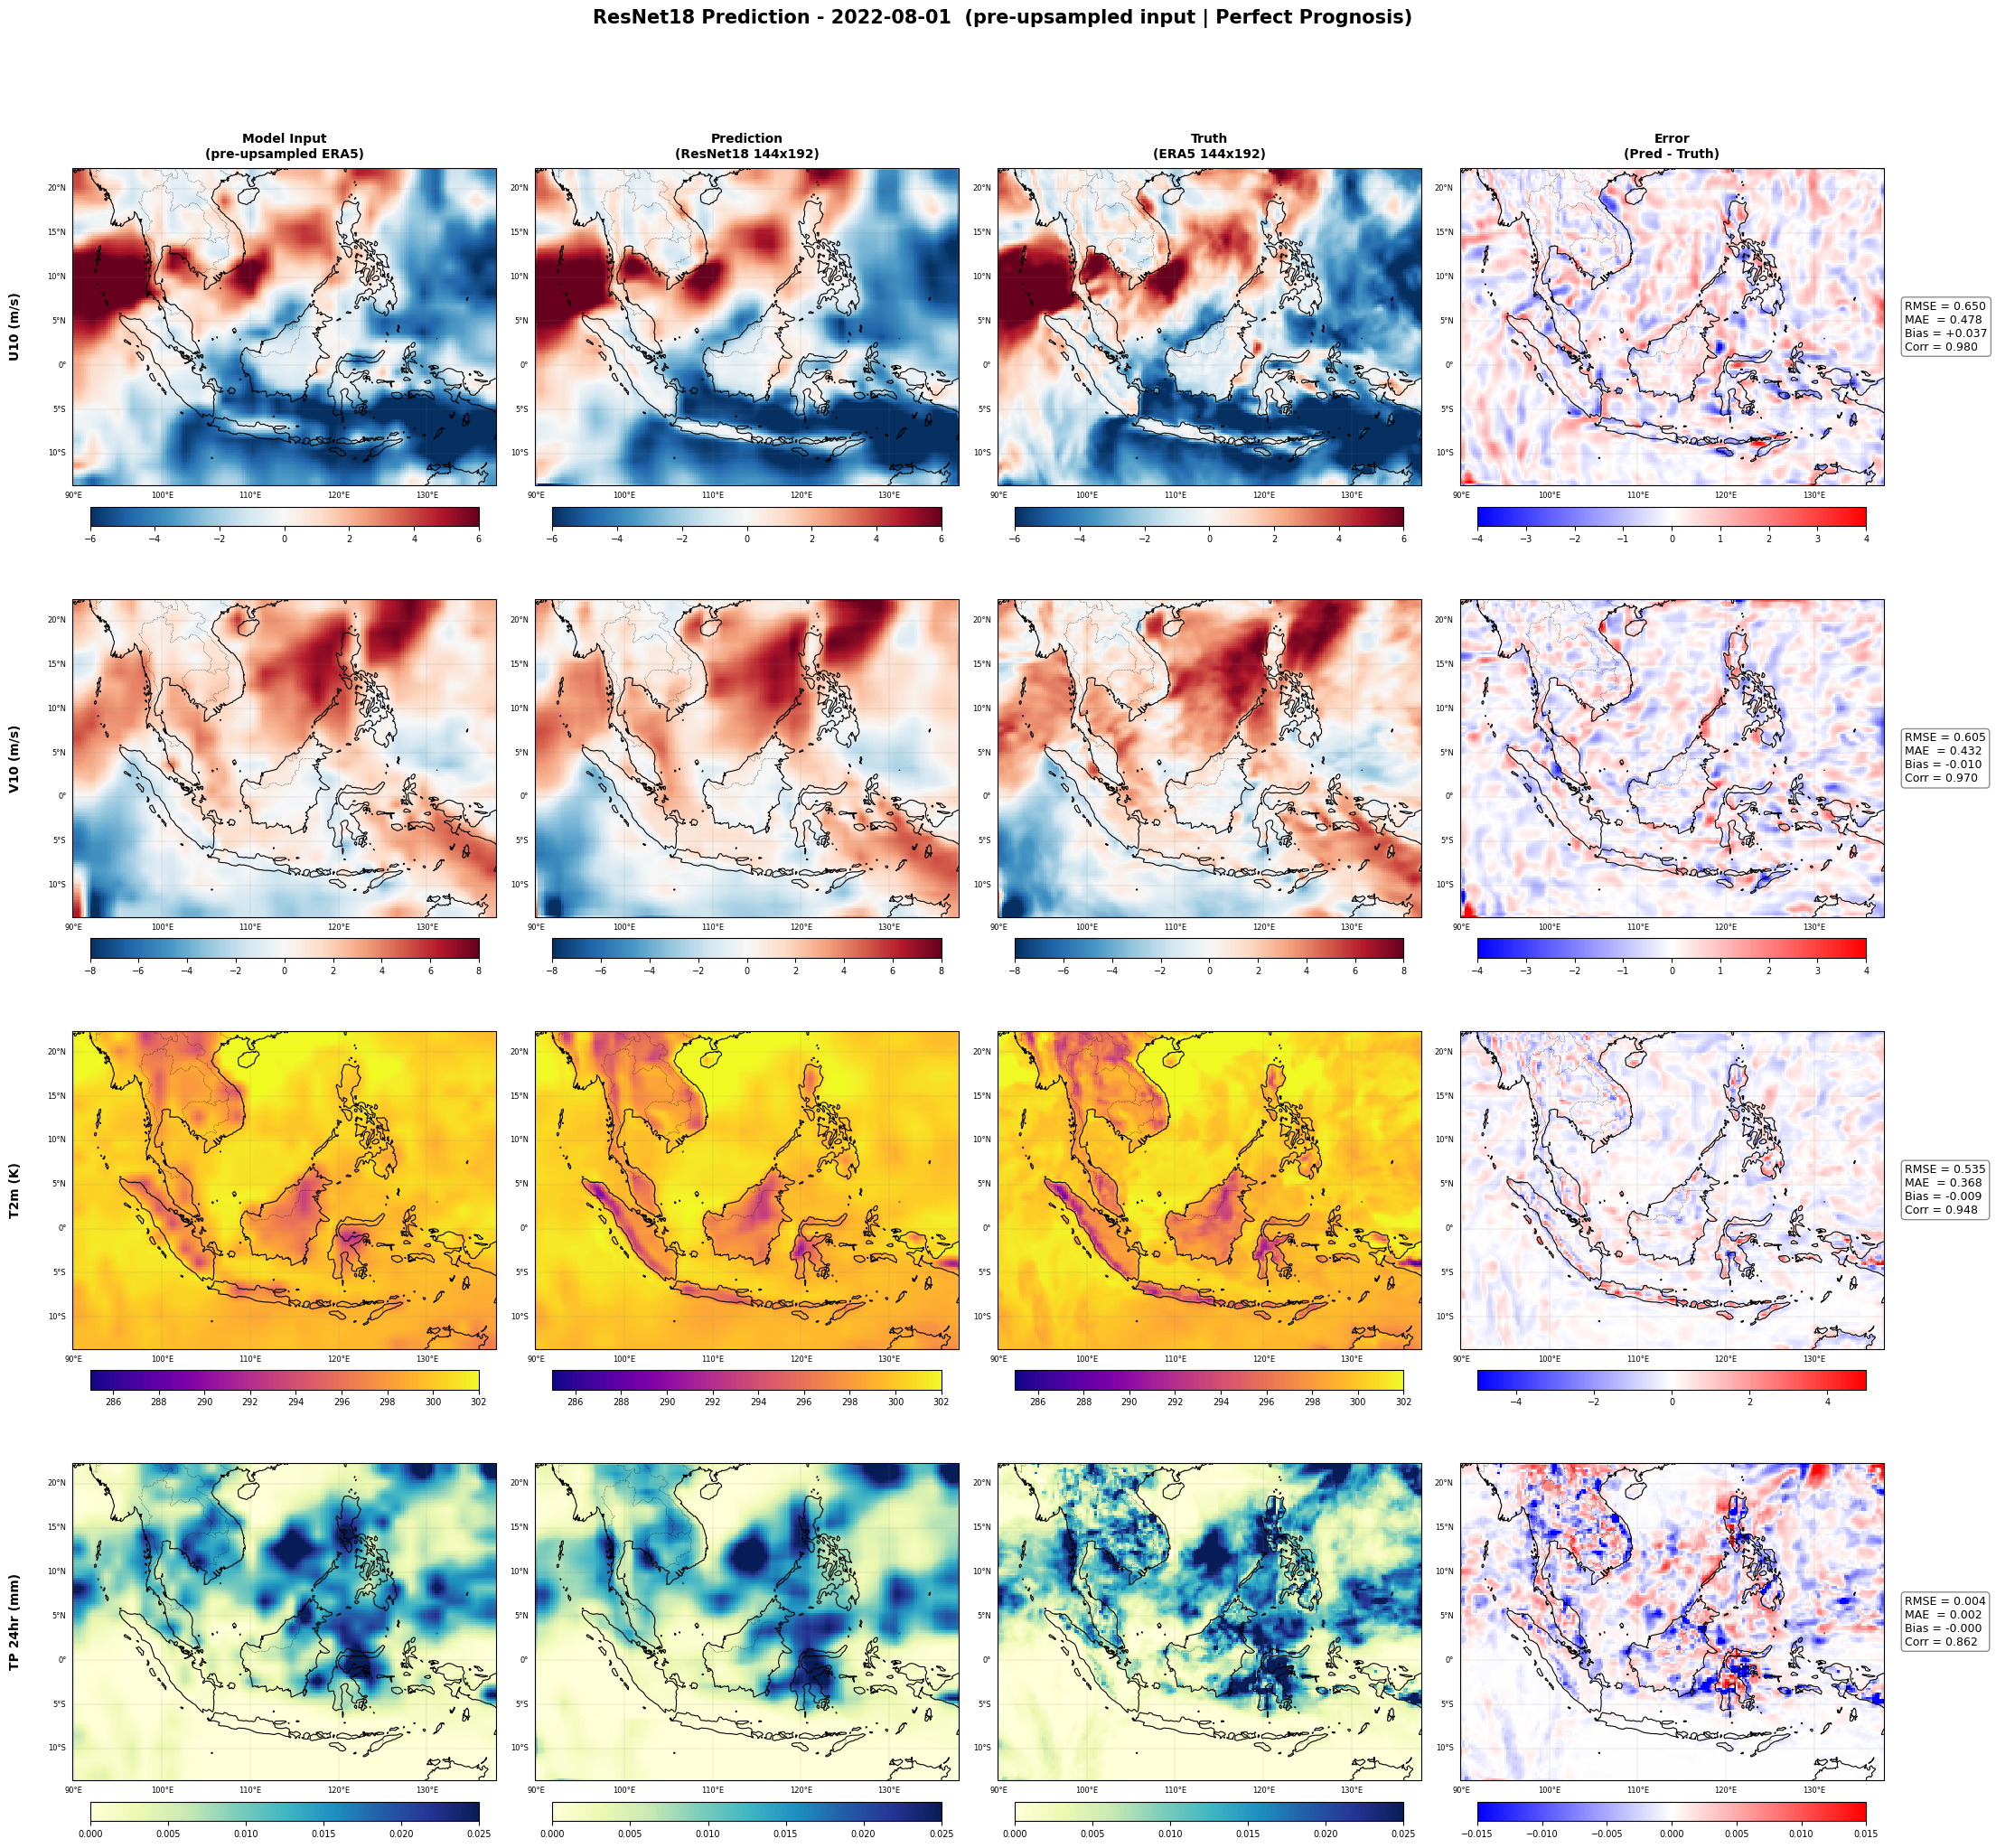

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch
import numpy as np

# Hardcoded color ranges (consistent across notebooks for head-to-head)
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]

# Colormaps - same as regrid notebook
cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

# Save chart config
_chart2_cfg = {
    'chart'          : 'spatial_eval',
    'target_date'    : str(target_date),
    'lead_days'      : 0,
    'figsize'        : [22, 20],
    'FIELD_VMIN'     : FIELD_VMIN,
    'FIELD_VMAX'     : FIELD_VMAX,
    'ERROR_LIM'      : ERROR_LIM,
    'VAR_LABELS_VIZ' : VAR_LABELS_VIZ,
    'cmaps_field'    : cmaps_field,
}
_json.dump(_chart2_cfg, open(os.path.join(RUN_DIR, 'chart_spatial_eval_config.json'), 'w'), indent=2)
_log('Chart config saved -> chart_spatial_eval_config.json')

# ==============================
# Find index in test split
# ==============================
test_times = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date)).time.values
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    raise ValueError(
        f"{target_date} not found in test set.\n"
        f"Available range: {test_times[0]} -> {test_times[-1]}"
    )
idx = idx[0]

# ==============================
# Get sample & predict
# ==============================
device = next(model.parameters()).device
model.eval()

X_sample = X_test[[idx]].to(device)
Y_sample = Y_test[[idx]]

with torch.no_grad():
    Y_pred_sample = model(X_sample).cpu()

# Denormalize - keep T2m in Kelvin (no K->C) to match regrid notebook
Y_mu  = norm_stats["Y_mean"]
Y_sig = norm_stats["Y_std"]
X_mu  = norm_stats["X_mean"]
X_sig = norm_stats["X_std"]

X_dn   = denormalize(X_sample.cpu(), X_mu, X_sig)[0]   # (4, 144, 192)
Y_true = denormalize(Y_sample,       Y_mu, Y_sig)[0]   # (4, 144, 192)
Y_pred = denormalize(Y_pred_sample,  Y_mu, Y_sig)[0]   # (4, 144, 192)

# ==============================
# Coordinate arrays
# ==============================
lons_hr = ds_tr_aligned.longitude.values
lats_hr = ds_tr_aligned.latitude.values

# ==============================
# Plot: 4 rows x 4 cols
# cols: Model input | Prediction | Truth | Error
# ==============================
proj   = ccrs.PlateCarree()
n_vars = len(VAR_LABELS_VIZ)

col_titles = [
    "Model Input\n(pre-upsampled ERA5)",
    "Prediction\n(ResNet18 144x192)",
    "Truth\n(ERA5 144x192)",
    "Error\n(Pred - Truth)",
]

fig, axes = plt.subplots(
    n_vars, 4,
    figsize=(22, 5 * n_vars),
    subplot_kw={"projection": proj},
)

for v in range(n_vars):
    input_v = X_dn[v].numpy()
    pred_v  = Y_pred[v].numpy()
    true_v  = Y_true[v].numpy()
    err_v   = pred_v - true_v

    cmap_f = cmaps_field[v]
    vmin = FIELD_VMIN[v]
    vmax = FIELD_VMAX[v]
    elim = ERROR_LIM[v]

    panels = [
        (lons_hr, lats_hr, input_v, cmap_f, vmin, vmax),
        (lons_hr, lats_hr, pred_v,  cmap_f, vmin, vmax),
        (lons_hr, lats_hr, true_v,  cmap_f, vmin, vmax),
        (lons_hr, lats_hr, err_v,   "bwr", -elim, elim),
    ]

    for col, (lons, lats, data, cmap, lo, hi) in enumerate(panels):
        ax = axes[v, col]

        if data.shape != (len(lats), len(lons)):
            data = data.T

        im = ax.pcolormesh(
            lons, lats, data,
            cmap=cmap, vmin=lo, vmax=hi,
            shading="nearest",
            transform=proj,
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
        ax.add_feature(cfeature.LAND,      facecolor="whitesmoke", zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor="lightcyan",  zorder=0)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
        gl.top_labels   = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}

        cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)

        if v == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight="bold", pad=8)
        if col == 0:
            ax.text(-0.15, 0.5, VAR_LABELS_VIZ[v], transform=ax.transAxes,
                    fontsize=10, fontweight="bold", va="center", rotation=90)

    rmse = float(np.sqrt(np.mean(err_v ** 2)))
    mae  = float(np.mean(np.abs(err_v)))
    bias = float(np.mean(err_v))
    pred_f = pred_v.ravel()
    true_f = true_v.ravel()
    corr = float(np.corrcoef(pred_f, true_f)[0, 1]) if np.std(pred_f) > 0 and np.std(true_f) > 0 else np.nan

    axes[v, -1].text(
        1.05, 0.5,
        f"RMSE = {rmse:.3f}\nMAE  = {mae:.3f}\nBias = {bias:+.3f}\nCorr = {corr:.3f}",
        transform=axes[v, -1].transAxes,
        fontsize=9, va="center",
        bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9),
    )

plt.suptitle(
    f"ResNet18 Prediction - {str(target_date)[:10]}  (pre-upsampled input | Perfect Prognosis)",
    fontsize=15, fontweight="bold", y=1.02,
)
plt.tight_layout()
save_fig(fig, f"resnet18_preupsample_eval_{str(target_date)[:10]}.png", dpi=150)
plt.show()


In [17]:
# ==========================================
# Helpers: compute_metrics / print_metrics
# ==========================================

def compute_metrics(preds_norm, targets_norm, Y_mu, Y_sig):
    """
    Denormalize both tensors, then compute per-variable
    RMSE, MAE, Bias, and Corr over the full (N, C, H, W) batch.
    Returns: dict  { VAR_LABELS[i]: {RMSE, MAE, Bias, Corr} }
    """
    p_dn = denormalize(preds_norm.clone(),   Y_mu, Y_sig).numpy()  # (N,C,H,W)
    t_dn = denormalize(targets_norm.clone(), Y_mu, Y_sig).numpy()

    results = {}
    for vi, label in enumerate(VAR_LABELS):
        p = p_dn[:, vi]; t = t_dn[:, vi]
        rmse = float(np.sqrt(np.mean((p - t) ** 2)))
        mae  = float(np.mean(np.abs(p - t)))
        bias = float(np.mean(p - t))
        pd_  = p - p.mean(); td_ = t - t.mean()
        with np.errstate(divide="ignore", invalid="ignore"):
            corr = float(
                np.sum(pd_ * td_) /
                (np.sqrt(np.sum(pd_**2) * np.sum(td_**2)) + 1e-12)
            )
        results[label] = {"RMSE": rmse, "MAE": mae, "Bias": bias, "Corr": corr}
    return results


def print_metrics(metrics: dict, prefix: str = "Metrics"):
    """Pretty-print a compute_metrics() result dict and log to runtime.log."""
    hdr  = f"\n{prefix}"
    line = "-" * 72
    print(hdr); print(line)
    _log(hdr)
    for label, m in metrics.items():
        r, a, b, c = m["RMSE"], m["MAE"], m["Bias"], m["Corr"]
        msg = (f"  {label:<22}  RMSE={r:8.4f}  MAE={a:8.4f}  "
               f"Bias={b:+8.4f}  Corr={c:6.4f}")
        print(msg); _log(msg)
    print(line)


# ==========================================
# evaluate_test — loads best checkpoint,
# runs inference on test_loader, returns
# metrics + raw prediction tensors
# ==========================================

def evaluate_test(model, test_loader, norm_stats,
                  device="cuda" if torch.cuda.is_available() else "cpu"):
    ckpt_path = os.path.join(RUN_DIR, "best_model.pt")
    _log(f"Loading checkpoint: {ckpt_path}")
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    model = model.to(device)
    model.eval()

    Y_mu  = norm_stats["Y_mean"]
    Y_sig = norm_stats["Y_std"]

    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            pred = model(X_batch.to(device))
            all_preds.append(pred.cpu())
            all_targets.append(Y_batch)

    all_preds   = torch.cat(all_preds,   dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    metrics = compute_metrics(all_preds, all_targets, Y_mu, Y_sig)
    print_metrics(metrics, prefix="🧪 Test Set Metrics")
    return metrics, all_preds, all_targets


test_metrics, test_preds, test_targets = evaluate_test(
    model, test_loader, norm_stats
)

[2026-04-08 19:29:05] Loading checkpoint: runs/20260408_184448/best_model.pt



🧪 Test Set Metrics
------------------------------------------------------------------------
[2026-04-08 19:29:08] 
🧪 Test Set Metrics
  U10 (m/s)               RMSE=  0.7513  MAE=  0.5302  Bias= -0.0114  Corr=0.9822
[2026-04-08 19:29:08]   U10 (m/s)               RMSE=  0.7513  MAE=  0.5302  Bias= -0.0114  Corr=0.9822
  V10 (m/s)               RMSE=  0.7317  MAE=  0.5181  Bias= -0.0076  Corr=0.9754
[2026-04-08 19:29:08]   V10 (m/s)               RMSE=  0.7317  MAE=  0.5181  Bias= -0.0076  Corr=0.9754
  T2m (K)                 RMSE=  0.6415  MAE=  0.4104  Bias= +0.0205  Corr=0.9543
[2026-04-08 19:29:08]   T2m (K)                 RMSE=  0.6415  MAE=  0.4104  Bias= +0.0205  Corr=0.9543
  TP 24hr (mm)            RMSE=  0.0059  MAE=  0.0025  Bias= -0.0006  Corr=0.8744
[2026-04-08 19:29:08]   TP 24hr (mm)            RMSE=  0.0059  MAE=  0.0025  Bias= -0.0006  Corr=0.8744
------------------------------------------------------------------------


In [18]:
# ==============================
# Aggregate test-set evaluation
# (Corrected Spatio-Temporal Metrics)
# ==============================
import numpy as np
import xarray as xr

Y_mu  = norm_stats["Y_mean"]
Y_sig = norm_stats["Y_std"]

# Denormalize model predictions/targets (physical space)
y_pred_phys = denormalize(test_preds.clone(), Y_mu, Y_sig).numpy()
y_true_phys = denormalize(test_targets.clone(), Y_mu, Y_sig).numpy()

# Build baseline exactly like QM notebook:
# low-res ds_fc test slice -> (fill NaN) -> linear interpolation to truth test grid
fc_test_lowres = ds_fc.sel(time=slice(test_start_date, test_end_date)).copy(deep=True)
tr_test_ds = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date))

# Match QM NaN handling before baseline interpolation
for v_name in VARS:
    if np.isnan(fc_test_lowres[v_name].values).any():
        fill_val = float(np.nanmean(fc_test_lowres[v_name].values))
        fc_test_lowres[v_name] = fc_test_lowres[v_name].fillna(fill_val)

# Compute baseline RMSE on full HR grid (time-aligned only, not lat/lon inner join)
baseline_rmse_by_var = {}
for v_name in VARS:
    low_da = fc_test_lowres[v_name].transpose('time', 'latitude', 'longitude')
    truth_da_xr = tr_test_ds[v_name].transpose('time', 'latitude', 'longitude')

    # Align only along time; keep each dataset's native spatial grids
    common_time = np.intersect1d(low_da.time.values, truth_da_xr.time.values)
    low_da = low_da.sel(time=common_time)
    truth_da_xr = truth_da_xr.sel(time=common_time)

    # Baseline: bilinear upsample LR -> HR truth grid
    base_da = low_da.interp(
        latitude=truth_da_xr.latitude,
        longitude=truth_da_xr.longitude,
        method='linear',
    )

    base_v_xr = base_da.values
    true_v_xr = truth_da_xr.values
    rmse_base_grid = np.sqrt(np.mean((base_v_xr - true_v_xr) ** 2, axis=0))
    baseline_rmse_by_var[v_name] = float(np.nanmean(rmse_base_grid))

print("\n" + "=" * 100)
print(f"{'Variable':<18} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print("=" * 100)

BASELINE_EPS = 1e-8

for v_idx, v_name in enumerate(VARS):
    pred_v = y_pred_phys[:, v_idx, :, :]
    true_v = y_true_phys[:, v_idx, :, :]

    n = min(pred_v.shape[0], true_v.shape[0])
    pred_v = pred_v[:n]
    true_v = true_v[:n]

    rmse_grid = np.sqrt(np.mean((pred_v - true_v) ** 2, axis=0))
    mae_grid = np.mean(np.abs(pred_v - true_v), axis=0)
    bias_grid = np.mean(pred_v - true_v, axis=0)

    pred_diff = pred_v - np.mean(pred_v, axis=0)
    true_diff = true_v - np.mean(true_v, axis=0)
    cov = np.sum(pred_diff * true_diff, axis=0)
    var_pred = np.sum(pred_diff ** 2, axis=0)
    var_true = np.sum(true_diff ** 2, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_grid = cov / np.sqrt(var_pred * var_true)

    rmse = float(np.nanmean(rmse_grid))
    mae = float(np.nanmean(mae_grid))
    bias = float(np.nanmean(bias_grid))
    corr = float(np.nanmean(corr_grid))

    rmse_base = baseline_rmse_by_var[v_name]
    skill = 1.0 - (rmse / rmse_base) if rmse_base > BASELINE_EPS else 0.0

    label = VAR_LABELS[v_idx]
    print(f"{label:<18} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

print("=" * 100)
print("\nSkill > 0 means SRUNet improves over bilinear interpolation baseline.")

# ── Save final test metrics to CSV ──────────────────────────────────────
import csv as _csv

_metrics_rows = []
for v_idx, v_name in enumerate(VARS):
    _pv = y_pred_phys[:, v_idx, :, :]
    _tv = y_true_phys[:, v_idx, :, :]
    _n = min(_pv.shape[0], _tv.shape[0])
    _pv = _pv[:_n]
    _tv = _tv[:_n]

    _rmse_g = np.sqrt(np.mean((_pv - _tv) ** 2, axis=0))
    _mae_g = np.mean(np.abs(_pv - _tv), axis=0)
    _bias_g = np.mean(_pv - _tv, axis=0)
    _pd = _pv - np.mean(_pv, axis=0)
    _td = _tv - np.mean(_tv, axis=0)
    _cov = np.sum(_pd * _td, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        _corr_g = _cov / np.sqrt(np.sum(_pd**2, axis=0) * np.sum(_td**2, axis=0))

    _rmse = float(np.nanmean(_rmse_g))
    _rbase = baseline_rmse_by_var[v_name]
    _metrics_rows.append({
        'variable': v_name,
        'label': VAR_LABELS[v_idx],
        'RMSE': _rmse,
        'MAE': float(np.nanmean(_mae_g)),
        'Bias': float(np.nanmean(_bias_g)),
        'Corr': float(np.nanmean(_corr_g)),
        'Baseline_RMSE': _rbase,
        'Skill': float(1.0 - (_rmse / _rbase)) if _rbase > BASELINE_EPS else 0.0,
    })

_csv_path = os.path.join(RUN_DIR, 'metrics.csv')
_fields = ['variable', 'label', 'RMSE', 'MAE', 'Bias', 'Corr', 'Baseline_RMSE', 'Skill']
with open(_csv_path, 'w', newline='') as _f:
    _w = _csv.DictWriter(_f, fieldnames=_fields)
    _w.writeheader()
    _w.writerows(_metrics_rows)
_log(f'Metrics saved → {_csv_path}')

# ── Log run completion ───────────────────────────────────────────────────
_total = _dt.datetime.now() - _run_start
_log(f'=== Run finished  total_elapsed={str(_total).split(".")[0]} ===')
_log(f'All outputs in: {RUN_DIR}')
print(f'\n✅ All outputs saved to: {RUN_DIR}')


Variable           |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill


U10 (m/s)          |   0.7068 |   0.5302 |  -0.0114 |   0.9397 |         0.6595 |  -0.0718


V10 (m/s)          |   0.6912 |   0.5181 |  -0.0076 |   0.9302 |         0.6327 |  -0.0923


T2m (K)            |   0.5183 |   0.4104 |  +0.0205 |   0.9199 |         0.5610 |  +0.0762


TP 24hr (mm)       |   0.0052 |   0.0025 |  -0.0006 |   0.8808 |         0.0046 |  -0.1302

Skill > 0 means SRUNet improves over bilinear interpolation baseline.


[2026-04-08 19:29:11] Metrics saved → runs/20260408_184448/metrics.csv
[2026-04-08 19:29:11] === Run finished  total_elapsed=0:44:22 ===
[2026-04-08 19:29:11] All outputs in: runs/20260408_184448

✅ All outputs saved to: runs/20260408_184448
